# Métodos estatísticos de detecção de anomalias

**Tema:** Aprendizado Não Supervisionado › Detecção de Anomalias

Os métodos mais simples — z-score, cercas de Tukey, Mahalanobis — ainda
resolvem uma parte grande dos problemas reais, **desde que** sejam usados
na versão robusta. Este notebook mede o mascaramento, compara as versões
clássica e robusta, calcula Mahalanobis do zero, mostra o MCD resistindo à
contaminação e transforma uma anomalia contextual em pontual.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.covariance import EmpiricalCovariance, MinCovDet

rng = np.random.default_rng(56)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Mascaramento: quanto de contaminação o z-score aguenta?

Tempo de resposta de uma API: requisições normais em torno de 200 ms e
uma fração crescente de requisições lentas em torno de 300 ms. Para cada
nível de contaminação, medimos quanto das lentas cada método detecta.

In [2]:
def z_classico(x):
    return (x - x.mean()) / x.std()

def z_robusto(x):
    mediana = np.median(x)
    mad = np.median(np.abs(x - mediana))
    return (x - mediana) / (1.4826 * mad)

def tukey(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

linhas = []
for frac in [0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30]:
    n_anom = int(2000 * frac)
    x = np.concatenate([rng.normal(200, 20, 2000 - n_anom), rng.normal(300, 10, n_anom)])
    anom = np.r_[np.zeros(2000 - n_anom, bool), np.ones(n_anom, bool)]
    linhas.append({"contaminação": f"{frac:.0%}",
                   "z clássico (recall)": np.mean(np.abs(z_classico(x))[anom] > 3),
                   "z robusto (recall)": np.mean(np.abs(z_robusto(x))[anom] > 3),
                   "Tukey (recall)": np.mean(tukey(x)[anom]),
                   "z robusto (falso alarme)": np.mean(np.abs(z_robusto(x))[~anom] > 3)})
print(pd.DataFrame(linhas).round(3).to_string(index=False))

contaminação  z clássico (recall)  z robusto (recall)  Tukey (recall)  z robusto (falso alarme)
          1%                1.000               1.000           1.000                     0.002
          3%                0.967               1.000           1.000                     0.000
          5%                0.740               1.000           1.000                     0.004
         10%                0.020               1.000           1.000                     0.000
         15%                0.000               0.993           1.000                     0.000
         20%                0.000               0.882           0.878                     0.001
         30%                0.000               0.010           0.000                     0.000


**Leitura esperada:** com 1% de contaminação, todos funcionam. A partir de
5–10%, o z clássico colapsa — as lentas inflam o desvio-padrão e se
escondem. O z robusto e as cercas de Tukey aguentam até cerca de 15%; com
20% começam a falhar e com 30% colapsam também: as lentas já são uma
fração grande o bastante para deslocar a mediana e inflar o MAD e o IQR.
Robusto não é invulnerável — o ponto de ruptura da mediana é 50%, mas um
limiar de 3 MAD deixa de separar os grupos muito antes disso.

## 2. Cauda longa: transforme antes de aplicar o limiar

Valor de compras: lognormal, sem nenhuma anomalia plantada. Quantos
"alertas" cada abordagem gera?

In [3]:
valores = rng.lognormal(np.log(120), 0.9, 10000)
print(f"z robusto em valor bruto : {np.mean(np.abs(z_robusto(valores)) > 3):.1%} de alertas")
print(f"z robusto em log(1+valor): {np.mean(np.abs(z_robusto(np.log1p(valores))) > 3):.1%} de alertas")

z robusto em valor bruto : 8.4% de alertas
z robusto em log(1+valor): 0.3% de alertas


Sem transformar, a cauda direita legítima vira uma enxurrada de alertas.
Depois do log, a distribuição fica aproximadamente simétrica, e a taxa de
alarme volta perto do esperado para uma normal (0,27%).

## 3. Mahalanobis do zero: o exemplo do `teoria.pdf`

In [4]:
S = np.array([[1.0, 0.8], [0.8, 1.0]])
S_inv = np.linalg.inv(S)
print("inversa da covariância:\n", S_inv.round(3))
for nome, p in [("A", np.array([1.0, 1.0])), ("B", np.array([1.0, -1.0]))]:
    d2 = p @ S_inv @ p
    print(f"{nome}={p}: distância euclidiana={np.linalg.norm(p):.3f} | D²={d2:.3f} | "
          f"p-valor (qui-quadrado, 2 gl) = {chi2.sf(d2, 2):.4f}")
print(f"limiar de 97,5%: {chi2.ppf(0.975, 2):.3f}")

inversa da covariância:
 [[ 2.778 -2.222]
 [-2.222  2.778]]
A=[1. 1.]: distância euclidiana=1.414 | D²=1.111 | p-valor (qui-quadrado, 2 gl) = 0.5738
B=[ 1. -1.]: distância euclidiana=1.414 | D²=10.000 | p-valor (qui-quadrado, 2 gl) = 0.0067
limiar de 97,5%: 7.378


## 4. Mahalanobis em dados reais, conferido contra o `scikit-learn`

In [5]:
n = 1000
X = rng.multivariate_normal([50, 120], [[25, 30], [30, 64]], n)   # ex.: peso e pressão
mu, cov = X.mean(axis=0), np.cov(X, rowvar=False)
d2_nosso = np.einsum("ij,jk,ik->i", X - mu, np.linalg.inv(cov), X - mu)
d2_sk = EmpiricalCovariance().fit(X).mahalanobis(X)
print(f"diferença máxima entre as implementações: {np.abs(d2_nosso - d2_sk * (n - 1) / n).max():.2e}")
print("(o sklearn usa covariância com divisor n; np.cov usa n-1 — daí o fator (n-1)/n)")
print(f"fração acima do limiar de 97,5%: {np.mean(d2_sk > chi2.ppf(0.975, 2)):.3f}  (esperado 0.025)")

diferença máxima entre as implementações: 5.33e-15
(o sklearn usa covariância com divisor n; np.cov usa n-1 — daí o fator (n-1)/n)
fração acima do limiar de 97,5%: 0.019  (esperado 0.025)


## 5. MCD: a covariância que resiste às anomalias

Contaminamos 10% da base com um aglomerado de anomalias que viola a
correlação. A covariância clássica é distorcida por elas; a do MCD, não.

      clássica: correlação estimada = +0.191 | anomalias detectadas = 43% | falsos alarmes = 1.0%
 MCD (robusta): correlação estimada = +0.768 | anomalias detectadas = 100% | falsos alarmes = 1.6%


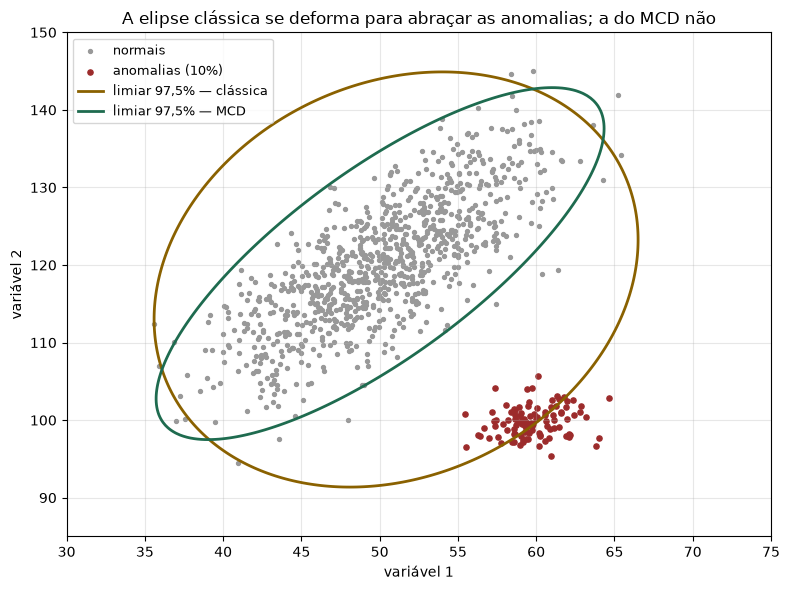

In [6]:
n_anom = 100
anomalias = rng.multivariate_normal([60, 100], [[4, 0], [0, 4]], n_anom)
Xc = np.vstack([X[: n - n_anom], anomalias])
e_anom = np.r_[np.zeros(n - n_anom, bool), np.ones(n_anom, bool)]
limiar = chi2.ppf(0.975, 2)

classica = EmpiricalCovariance().fit(Xc)
robusta = MinCovDet(random_state=0).fit(Xc)
for nome, est in [("clássica", classica), ("MCD (robusta)", robusta)]:
    d2 = est.mahalanobis(Xc)
    print(f"{nome:>14s}: correlação estimada = "
          f"{est.covariance_[0, 1] / np.sqrt(est.covariance_[0, 0] * est.covariance_[1, 1]):+.3f} | "
          f"anomalias detectadas = {np.mean(d2[e_anom] > limiar):.0%} | "
          f"falsos alarmes = {np.mean(d2[~e_anom] > limiar):.1%}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(*Xc[~e_anom].T, s=8, color="#999999", label="normais")
ax.scatter(*Xc[e_anom].T, s=14, color=VERMELHO, label="anomalias (10%)")
gx, gy = np.meshgrid(np.linspace(30, 75, 200), np.linspace(85, 150, 200))
grade = np.c_[gx.ravel(), gy.ravel()]
for est, cor in [(classica, AMBAR), (robusta, VERDE)]:
    ax.contour(gx, gy, est.mahalanobis(grade).reshape(gx.shape), levels=[limiar],
               colors=cor, linewidths=2)
ax.plot([], [], color=AMBAR, lw=2, label="limiar 97,5% — clássica")  # entradas da legenda
ax.plot([], [], color=VERDE, lw=2, label="limiar 97,5% — MCD")
ax.set_xlabel("variável 1"); ax.set_ylabel("variável 2"); ax.legend(fontsize=9)
ax.set_title("A elipse clássica se deforma para abraçar as anomalias; a do MCD não")
plt.tight_layout(); plt.show()

## 6. Anomalia contextual vira pontual com a feature certa

Temperatura diária de uma câmara fria ao longo de dois anos, com
sazonalidade (a câmara esquenta um pouco no verão) e três anomalias
plantadas em pleno inverno — valores que seriam normais no verão.

            z robusto global:   0 alertas, 0 das 3 anomalias
 z robusto do resíduo mensal:   5 alertas, 3 das 3 anomalias


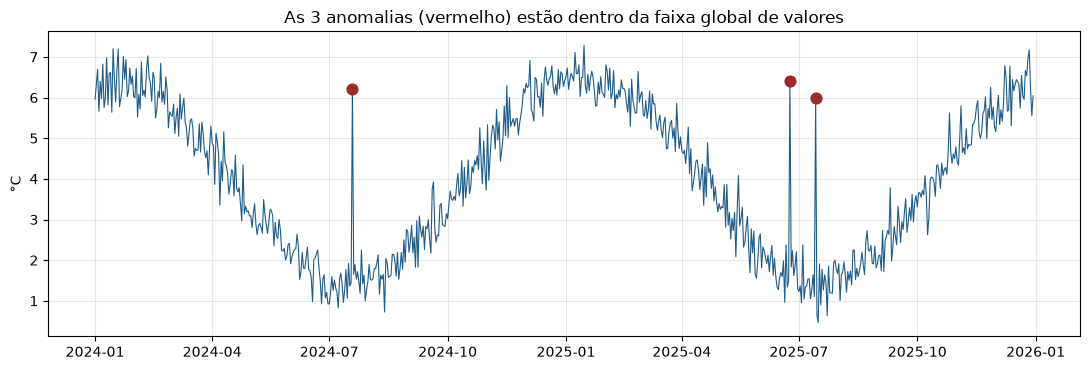

In [7]:
dias = pd.date_range("2024-01-01", periods=730, freq="D")
# pico em meados de janeiro (verão no hemisfério sul), vale em meados de julho
sazonal = 4 + 2.5 * np.sin(2 * np.pi * (dias.dayofyear.to_numpy() + 76) / 365)
temp = sazonal + rng.normal(0, 0.4, len(dias))
idx_anom = [200, 540, 560]      # meses de inverno no hemisfério sul
temp[idx_anom] = [6.2, 6.4, 6.0]
serie = pd.DataFrame({"temp": temp}, index=dias)
serie["mes"] = serie.index.month

z_global = z_robusto(serie["temp"].to_numpy())
# a feature contextual: desvio em relação à mediana do mesmo mês
residuo = serie["temp"] - serie.groupby("mes")["temp"].transform("median")
z_contexto = z_robusto(residuo.to_numpy())

for nome, z in [("z robusto global", z_global), ("z robusto do resíduo mensal", z_contexto)]:
    alertas = np.where(np.abs(z) > 3)[0]
    acertos = len(set(alertas) & set(idx_anom))
    print(f"{nome:>28s}: {len(alertas):>3d} alertas, {acertos} das 3 anomalias")

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(serie.index, serie["temp"], color=AZUL, lw=0.8)
ax.scatter(serie.index[idx_anom], serie["temp"].iloc[idx_anom], color=VERMELHO, s=60, zorder=5)
ax.set_ylabel("°C"); ax.set_title("As 3 anomalias (vermelho) estão dentro da faixa global de valores")
plt.tight_layout(); plt.show()

Pelo valor bruto, 6 °C é uma temperatura comum (acontece todo verão) e o
z global não vê nada. Subtraindo a mediana do mês — a feature que
carrega o **contexto** —, as três anomalias viram pontos extremos. É o
mesmo raciocínio que o tema 7 (Séries Temporais) formaliza com
decomposição sazonal.

## O que levar deste notebook

- Média e desvio-padrão são contaminados pelas próprias anomalias; a
  mediana e o MAD não. Use sempre a versão robusta.
- Transforme variáveis de cauda longa antes de aplicar qualquer limiar.
- Mahalanobis vê anomalias na combinação de colunas e tem limiar
  probabilístico — com covariância robusta (MCD), não a clássica.
- Anomalias contextuais viram pontuais com uma feature de contexto.

→ Próximo: **Isolation Forest e LOF**, métodos que não supõem forma
nenhuma para o normal.